# Colour - Checker Detection - Examples: Inference

This notebook showcases machine learning inference retated colour checker detection examples.

The inference is performed by [Ultralytics YOLOv8](https://github.com/ultralytics/ultralytics)

The model is published on [HuggingFace](<https://huggingface.co/colour-science/colour-checker-detection-models), it was trained on a purposely constructed [dataset](https://huggingface.co/datasets/colour-science/colour-checker-detection-dataset).

<div class="alert alert-warning">
The model has only been trained on <em>ColorChecker Classic 24</em> images and will not work with <em>ColorChecker Nano</em> or <em>ColorChecker SG</em> images.
</div>

<div class="alert alert-danger">
Inference is performed by a script licensed under the terms of the <em>GNU Affero General Public License v3.0</em> as it uses the <em>Ultralytics YOLOv8</em> API which is incompatible with the <em>BSD-3-Clause</em>.
</div>

<div class="alert alert-danger">
This notebook also uses the <em>Ultralytics YOLOv8</em> API directly at the end for demonstration purposes and is thus also licensed under the terms of the <em>GNU Affero General Public License v3.0</em>.
</div>

<div class="alert alert-info">
The original *.CR2 files were processed with <em>dcraw</em> as follows: <code>dcraw -T -g 2.4 12.92 *.CR2</code> and then resized and converted to *.png with <em>Image Magick</em> as follows: <code>mogrify -resize 50% -format png *.tiff</code>.
</div>

In [1]:
import glob
import numpy as np
import os

import colour

from colour_checker_detection import (
    ROOT_RESOURCES_EXAMPLES,
    detect_colour_checkers_inference)

colour.plotting.colour_style()

colour.utilities.describe_environment();

*                                                                             *
*   Interpreter :                                                             *
*       python : 3.10.16 (main, Dec  4 2024, 08:53:37) [GCC 9.4.0]            *
*                                                                             *
*   colour-science.org :                                                      *
*       colour : v0.1.2-248-g07bf5c1                                          *
*       colour-checker-detection : v0.1.2-248-g07bf5c1                        *
*                                                                             *
*   Runtime :                                                                 *
*       imageio : 2.36.1                                                      *
*       matplotlib : 3.10.0                                                   *
*       networkx : 3.4.2                                                      *
*       numpy : 2.2.1                   

## Images

In [2]:
%matplotlib inline

In [3]:
COLOUR_CHECKER_IMAGE_PATHS = glob.glob(
    os.path.join(ROOT_RESOURCES_EXAMPLES, 'detection', '*25*.png'))

COLOUR_CHECKER_IMAGES = [
    colour.cctf_decoding(colour.io.read_image(path))
    for path in COLOUR_CHECKER_IMAGE_PATHS
]

for image in COLOUR_CHECKER_IMAGES:
    colour.plotting.plot_image(colour.cctf_encoding(image));

## Detection

In [4]:
SWATCHES = []
for image in COLOUR_CHECKER_IMAGES:
    for colour_checker_data in detect_colour_checkers_inference(
        image, additional_data=True):
        
        swatch_colours, swatch_masks, colour_checker_image, quadrilateral = (
            colour_checker_data.values)
        SWATCHES.append(swatch_colours)
        
        # Using the additional data to plot the colour checker and masks.
        masks_i = np.zeros(colour_checker_image.shape)
        for i, mask in enumerate(swatch_masks):
            masks_i[mask[0]:mask[1], mask[2]:mask[3], ...] = 1
        
        colour.plotting.plot_image(
            colour.cctf_encoding(
                np.clip(colour_checker_image + masks_i * 0.25, 0, 1)));

## Colour Fitting

In [5]:
D65 = colour.CCS_ILLUMINANTS['CIE 1931 2 Degree Standard Observer']['D65']
REFERENCE_COLOUR_CHECKER = colour.CCS_COLOURCHECKERS[
    'ColorChecker24 - After November 2014']

colour_checker_rows = REFERENCE_COLOUR_CHECKER.rows
colour_checker_columns = REFERENCE_COLOUR_CHECKER.columns

# NOTE: The reference swatches values as produced by the "colour.XYZ_to_RGB"
# definition are linear by default.
# See https://github.com/colour-science/colour-checker-detection/discussions/59
# for more information.
REFERENCE_SWATCHES = colour.XYZ_to_RGB(
        colour.xyY_to_XYZ(list(REFERENCE_COLOUR_CHECKER.data.values())),
        'sRGB', REFERENCE_COLOUR_CHECKER.illuminant)

for i, swatches in enumerate(SWATCHES):
    swatches_xyY = colour.XYZ_to_xyY(colour.RGB_to_XYZ(
        swatches, 'sRGB', D65))

    colour_checker = colour.characterisation.ColourChecker(
        os.path.basename(COLOUR_CHECKER_IMAGE_PATHS[i]),
        dict(zip(REFERENCE_COLOUR_CHECKER.data.keys(), swatches_xyY)),
        D65, colour_checker_rows, colour_checker_columns)
    
    colour.plotting.plot_multi_colour_checkers(
        [REFERENCE_COLOUR_CHECKER, colour_checker])
    
    swatches_f = colour.colour_correction(swatches, swatches, REFERENCE_SWATCHES)
    swatches_f_xyY = colour.XYZ_to_xyY(colour.RGB_to_XYZ(
        swatches_f, 'sRGB', D65))
    colour_checker = colour.characterisation.ColourChecker(
        '{0} - CC'.format(os.path.basename(COLOUR_CHECKER_IMAGE_PATHS[i])),
        dict(zip(REFERENCE_COLOUR_CHECKER.data.keys(), swatches_f_xyY)),
        D65, colour_checker_rows, colour_checker_columns)
    
    colour.plotting.plot_multi_colour_checkers(
        [REFERENCE_COLOUR_CHECKER, colour_checker])

    colour.plotting.plot_image(colour.cctf_encoding(
        colour.colour_correction(
            COLOUR_CHECKER_IMAGES[i], swatches, REFERENCE_SWATCHES)));

## Additional Data Plotting

In [6]:
for image in COLOUR_CHECKER_IMAGES:
    for colour_checker_data in detect_colour_checkers_inference(
            image, show=True):
        pass

# Failures

The current inference process is prone to fail if the image is not that of a *ColorChecker Classic 24*, especially with the *ColorChecker Passport*:

<div class="alert alert-info">
The image path can also be passed directly to the detection definition and that it is possible to control the image decoding directly.
</div>

In [10]:
(os.path.join(ROOT_RESOURCES_EXAMPLES, "colour-checker-detection-dataset/test/images", "0015.png"))

'/home/valentina/Documents/colour-checker-detection/colour_checker_detection/resources/colour-checker-detection-examples-datasets/colour-checker-detection-dataset/test/images/0015.png'

INFO:root:Downloading "https://huggingface.co/colour-science/colour-checker-detection-models/resolve/main/models/colour-checker-detection-l-seg.pt" model...


100%|██████████| 88.3M/88.3M [00:12<00:00, 7.34MB/s]
/home/valentina/Documents/colour-checker-detection/env/lib/python3.10/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: "OpenImageIO" related API features are not available, switching to "Imageio"!
  warn(*args, **kwargs)  # noqa: B028



0: 864x1280 1 ColorCheckerClassic24, 114.6ms
Speed: 35.8ms preprocess, 114.6ms inference, 252.8ms postprocess per image at shape (1, 3, 864, 1280)


/home/valentina/Documents/colour-checker-detection/env/lib/python3.10/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: "OpenImageIO" related API features are not available, switching to "Imageio"!
  warn(*args, **kwargs)  # noqa: B028


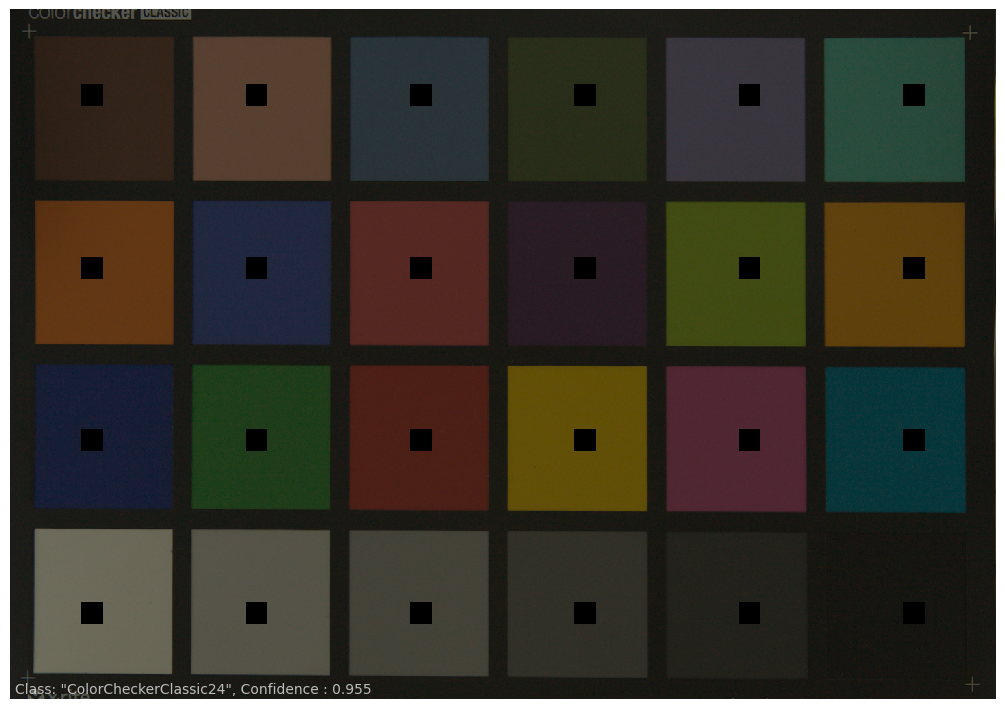

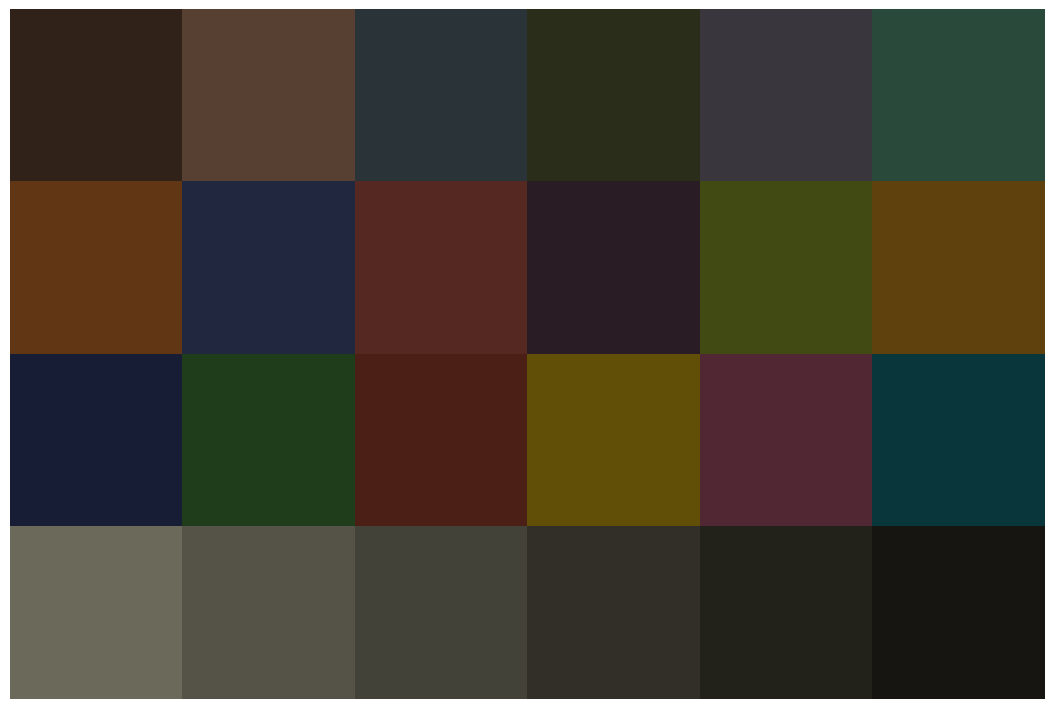

In [11]:
COLOUR_CHECKER_IMAGE_PATH = next(
    iter(glob.glob(os.path.join(ROOT_RESOURCES_EXAMPLES, "colour-checker-detection-dataset/test/images", "0015.png")))
)

for colour_checker_data in detect_colour_checkers_inference(
    COLOUR_CHECKER_IMAGE_PATH, apply_cctf_decoding=True, show=True
):
    pass


In this specific case, it is possible to transform the image post-detection and horizontally compress it to have better swatch masks placement:

/home/valentina/Documents/colour-checker-detection/env/lib/python3.10/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: "OpenImageIO" related API features are not available, switching to "Imageio"!
  warn(*args, **kwargs)  # noqa: B028



0: 864x1280 1 ColorCheckerClassic24, 110.2ms
Speed: 29.3ms preprocess, 110.2ms inference, 265.9ms postprocess per image at shape (1, 3, 864, 1280)


/home/valentina/Documents/colour-checker-detection/env/lib/python3.10/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: "OpenImageIO" related API features are not available, switching to "Imageio"!
  warn(*args, **kwargs)  # noqa: B028


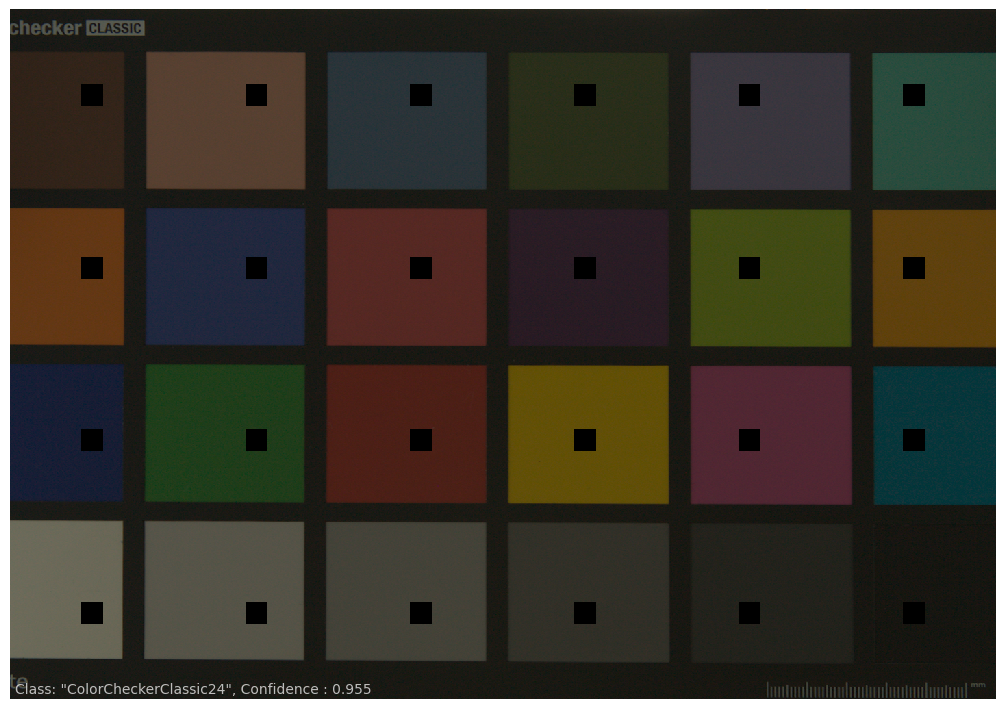

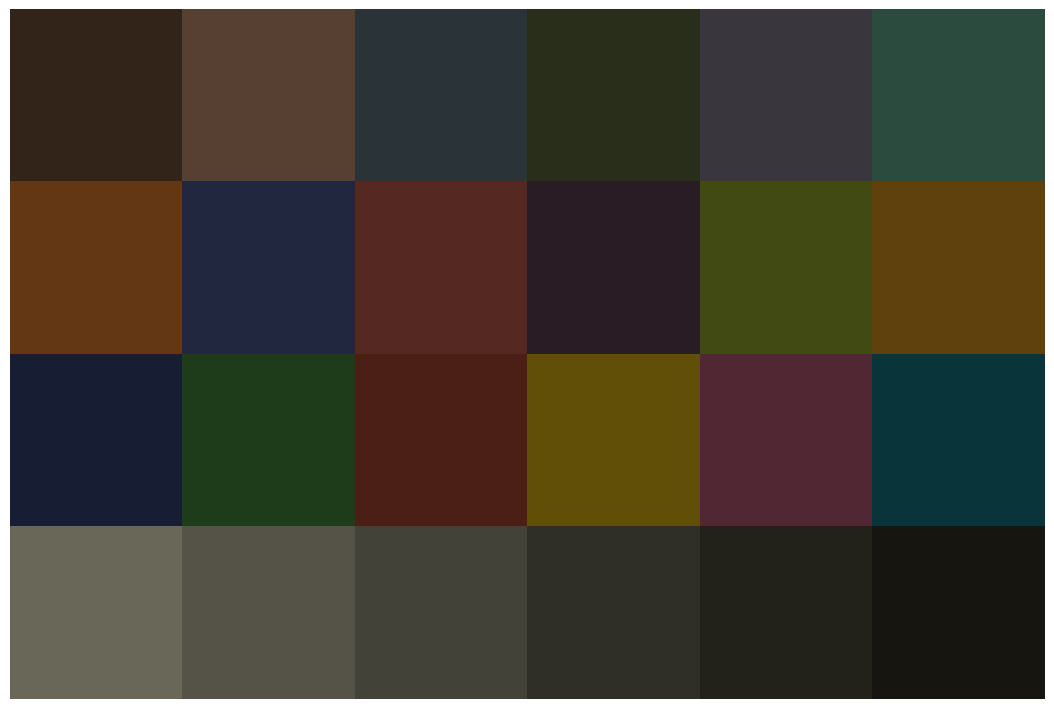

In [12]:
for colour_checker_data in detect_colour_checkers_inference(
    COLOUR_CHECKER_IMAGE_PATH,
    apply_cctf_decoding=True,
    inferred_confidence=0.875,
    transform={"scale": (1.15, 1)},
    show=True,
):
    pass


# Faster Inference with Custom Inferencer

In [13]:
import time
from ultralytics import YOLO


def inferencer_agpl(image, **kwargs):
    model = YOLO(
        os.path.join(
            os.path.expanduser("~"),
            ".colour-science",
            "colour-checker-detection",
            "colour-checker-detection-l-seg.pt",
        ),
    )
    data = []

    # NOTE: YOLOv8 expects "BGR" arrays.
    if isinstance(image, np.ndarray):
        image = image[..., ::-1]

    image = colour.io.convert_bit_depth(image, np.uint8.__name__)

    # `device=0` for CUDA GPU
    for result in model(image):
        if result.boxes is None:
            continue

        if result.masks is None:
            continue

        data_boxes = result.boxes.data
        data_masks = result.masks.data

        for i in range(data_boxes.shape[0]):
            data.append(
                (
                    data_boxes[i, 4].cpu().numpy(),
                    data_boxes[i, 5].cpu().numpy(),
                    data_masks[i].data.cpu().numpy(),
                )
            )

    return data

print("Default Inferencer (Script via Sub-Process)")
for image in COLOUR_CHECKER_IMAGES:
    start = time.perf_counter()
    for colour_checker_data in detect_colour_checkers_inference(image):
        pass

    print(f"Total Inference Time: {time.perf_counter() - start:.3f} seconds")

print("\n")

print("Custom Inferencer")
for image in COLOUR_CHECKER_IMAGES:
    start = time.perf_counter()
    for colour_checker_data in detect_colour_checkers_inference(
        image, inferencer=inferencer_agpl
    ):
        pass

    print(f"Total Inference Time: {time.perf_counter() - start:.3f} seconds")

Default Inferencer (Script via Sub-Process)


Custom Inferencer
